# 🌊 Prédiction de la Probabilité d'Inondation avec LightGBM
## Projet Fil Conducteur — Formation Data Scientist
### Africa Tech Up Tour

---

**Auteur :** Judicaël Karol DOBOEVI  
**Formation :** Génie Mathématique et Modélisation — 1ère année  
**Institution :** École Nationale Supérieure de Génie Mathématique et Modélisation (ENSGMM), Bénin  
**Dataset :** [Kaggle Playground Series S4E5](https://www.kaggle.com/competitions/playground-series-s4e5)  
**Score :** 0.869 (R²)

---

## 📋 Contexte et Objectif

Les inondations figurent parmi les catastrophes naturelles les plus dévastatrices, affectant chaque année des millions de personnes à travers le monde — et particulièrement en Afrique subsaharienne.  
Ce projet vise à construire un **modèle de régression supervisé** capable de prédire la probabilité d'occurrence d'une inondation en fonction de 20 variables environnementales, climatiques, et socio-économiques.

**Algorithme utilisé :** LightGBM (Light Gradient Boosting Machine)  
**Métrique d'évaluation :** Coefficient de détermination R²

## 🗂️ Plan du Notebook

1. [Chargement des données](#section-1)
2. [Analyse exploratoire (EDA)](#section-2)
3. [Analyse des corrélations](#section-3)
4. [Ingénierie des variables (Feature Engineering)](#section-4)
5. [Importance des variables](#section-5)
6. [Entraînement avec validation croisée (K-Fold)](#section-6)
7. [Évaluation et analyse des résidus](#section-7)

---
## 0. Importation des bibliothèques <a id='section-0'></a>

In [1]:
# ── Bibliothèques standard ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Style global
plt.rcParams.update({
    'figure.facecolor': '#f9f9f9',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'DejaVu Sans',
})
PALETTE = 'Blues_d'
ACCENT  = '#1f77b4'

# ── Machine Learning ────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import lightgbm as lgb

---
## 1. Chargement des données <a id='section-1'></a>

In [3]:
# ── Lecture des fichiers CSV ─────────────────────────────────────────────────
# Adapter les chemins selon l'environnement (Kaggle ou local)
DATA_PATH = "C:\\Users\\ADMIN\\Downloads\\playground-series-s4e5\\"  # Modifier si nécessaire

df_train  = pd.read_csv(DATA_PATH + "train.csv")
df_test   = pd.read_csv(DATA_PATH + "test.csv")

print(f" Jeu d'entraînement : {df_train.shape[0]:,} lignes × {df_train.shape[1]} colonnes")
print(f" Jeu de test        : {df_test.shape[0]:,} lignes × {df_test.shape[1]} colonnes")
print()
df_train.head()

 Jeu d'entraînement : 1,117,957 lignes × 22 colonnes
 Jeu de test        : 745,305 lignes × 21 colonnes



,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


---
## 2. Analyse Exploratoire des Données (EDA) <a id='section-2'></a>

L'analyse exploratoire vise à comprendre la structure du dataset, identifier d'éventuelles anomalies et appréhender la distribution des variables.

In [4]:
# ── 2.1 Informations générales ───────────────────────────────────────────────
print("=" * 65)
print("  INFORMATIONS GÉNÉRALES DU DATASET")
print("=" * 65)
df_train.info()

  INFORMATIONS GÉNÉRALES DU DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDis

In [5]:
# ── 2.2 Vérification des valeurs manquantes ──────────────────────────────────
missing = df_train.isnull().sum()
print(" Valeurs manquantes par colonne :")
print(missing[missing > 0] if missing.any() else "Aucune valeur manquante détectée.")

 Valeurs manquantes par colonne :
Aucune valeur manquante détectée.


In [7]:
# ── 2.3 Statistiques descriptives ───────────────────────────────────────────
df_train.describe().round(3)

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,...,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000,1117957.000
mean,558978.000,4.921,4.927,4.955,4.942,4.943,4.934,4.956,4.928,4.943,...,4.947,4.954,4.931,4.929,4.926,4.928,4.951,4.941,4.939,0.504
std,322726.532,2.056,2.094,2.072,2.052,2.083,2.058,2.083,2.066,2.069,...,2.072,2.089,2.078,2.082,2.065,2.074,2.069,2.081,2.090,0.051
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.285
25%,279489.000,3.000,3.000,4.000,4.000,3.000,3.000,4.000,3.000,3.000,...,4.000,3.000,3.000,3.000,3.000,3.000,4.000,3.000,3.000,0.470
50%,558978.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,...,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,0.505
75%,838467.000,6.000,6.000,6.000,6.000,6.000,6.000,6.000,6.000,6.000,...,6.000,6.000,6.000,6.000,6.000,6.000,6.000,6.000,6.000,0.540
max,1117956.000,16.000,18.000,16.000,17.000,17.000,17.000,16.000,16.000,16.000,...,17.000,17.000,16.000,16.000,17.000,18.000,19.000,16.000,16.000,0.725


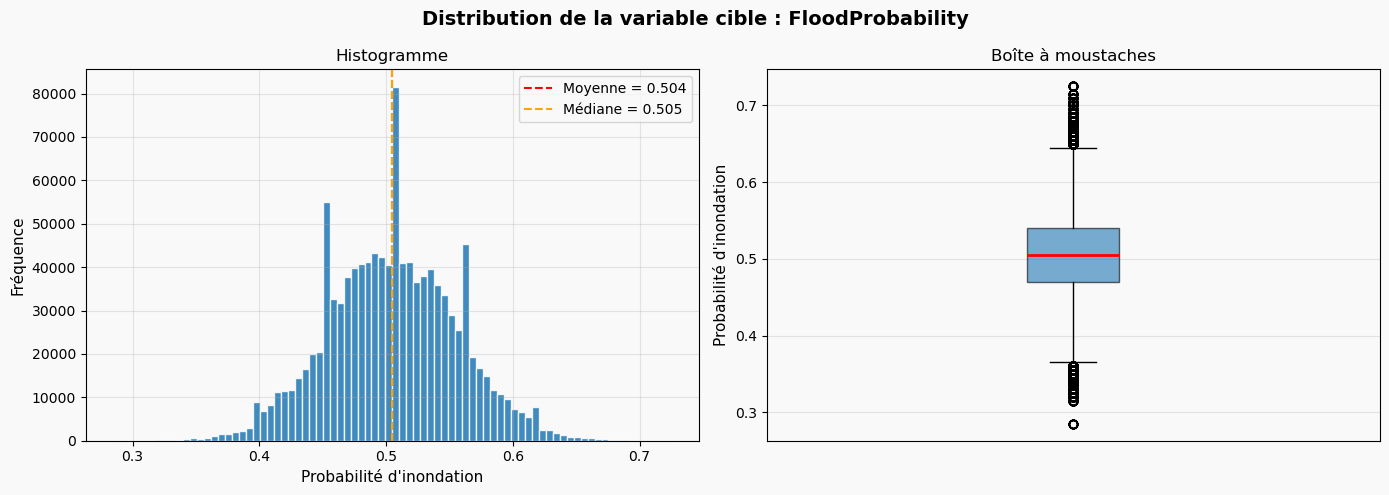


Résumé statistique de FloodProbability :
   Min     = 0.2850
   Max     = 0.7250
   Moyenne = 0.5045
   Écart-type = 0.0510
   Asymétrie (skewness) = 0.0472


In [8]:
# ── 2.4 Distribution de la variable cible ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution de la variable cible : FloodProbability", fontsize=14, fontweight='bold')

# Histogramme
axes[0].hist(df_train['FloodProbability'], bins=80, color=ACCENT, edgecolor='white', alpha=0.85)
axes[0].set_xlabel("Probabilité d'inondation", fontsize=11)
axes[0].set_ylabel("Fréquence", fontsize=11)
axes[0].set_title("Histogramme")
axes[0].axvline(df_train['FloodProbability'].mean(), color='red', linestyle='--', label=f"Moyenne = {df_train['FloodProbability'].mean():.3f}")
axes[0].axvline(df_train['FloodProbability'].median(), color='orange', linestyle='--', label=f"Médiane = {df_train['FloodProbability'].median():.3f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(df_train['FloodProbability'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=ACCENT, alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel("Probabilité d'inondation", fontsize=11)
axes[1].set_title("Boîte à moustaches")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f"\nRésumé statistique de FloodProbability :")
print(f"   Min     = {df_train['FloodProbability'].min():.4f}")
print(f"   Max     = {df_train['FloodProbability'].max():.4f}")
print(f"   Moyenne = {df_train['FloodProbability'].mean():.4f}")
print(f"   Écart-type = {df_train['FloodProbability'].std():.4f}")
print(f"   Asymétrie (skewness) = {df_train['FloodProbability'].skew():.4f}")

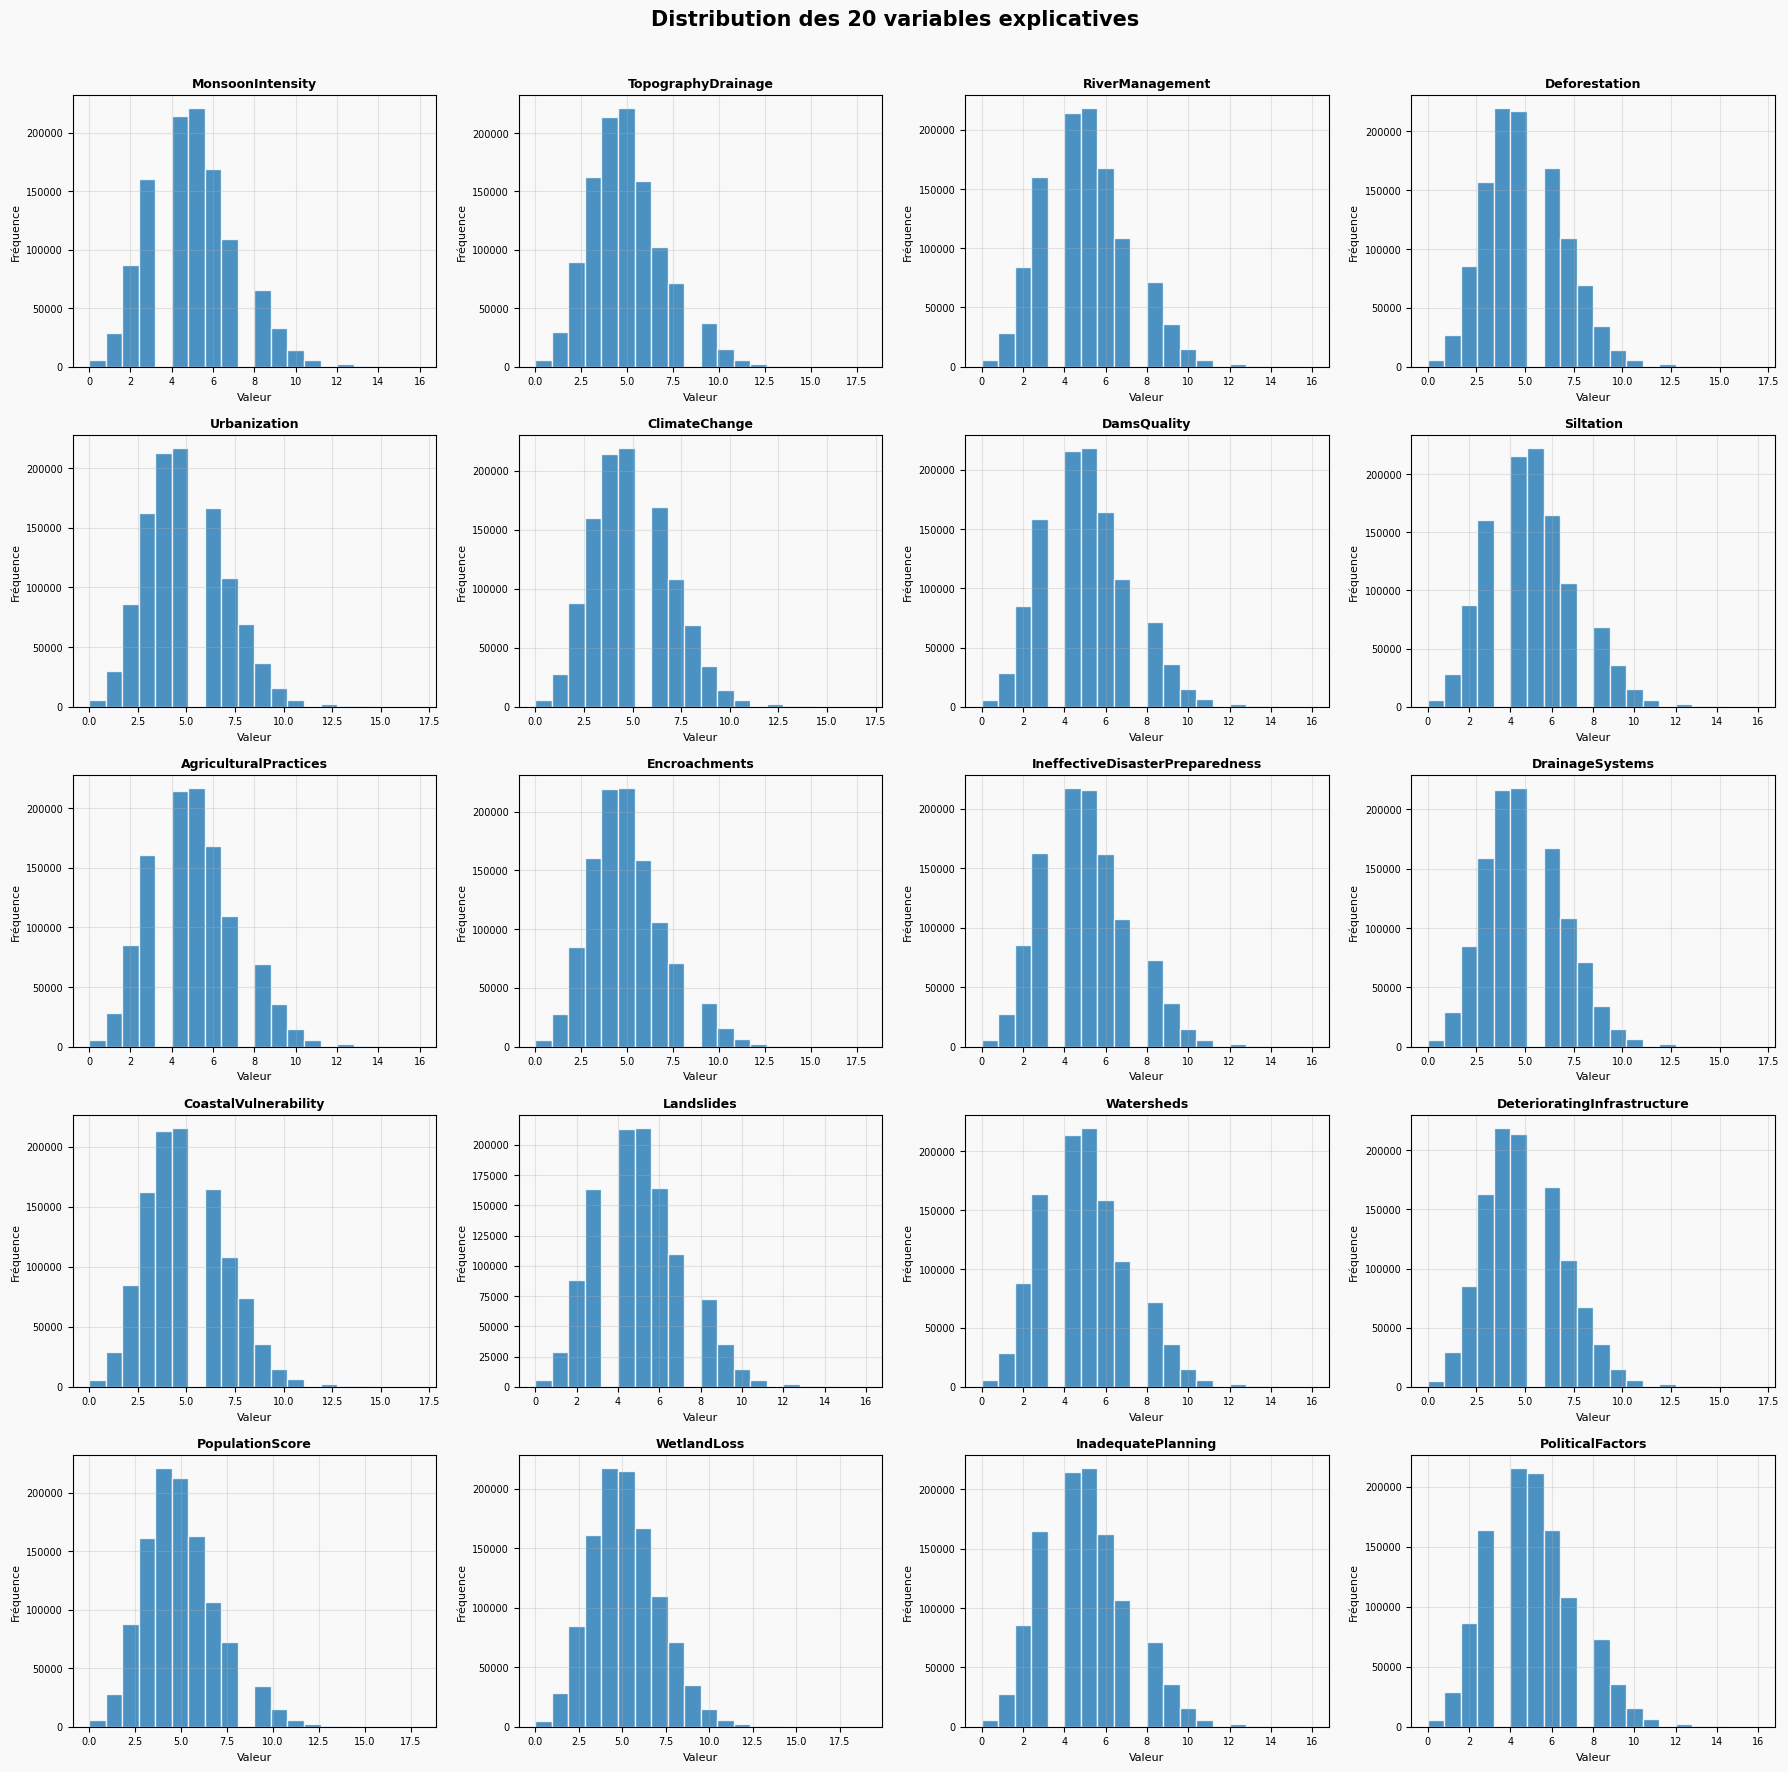

In [9]:
# ── 2.5 Distribution des variables explicatives ──────────────────────────────
num_cols = [
    'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
    'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
    'Siltation', 'AgriculturalPractices', 'Encroachments',
    'IneffectiveDisasterPreparedness', 'DrainageSystems',
    'CoastalVulnerability', 'Landslides', 'Watersheds',
    'DeterioratingInfrastructure', 'PopulationScore',
    'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors'
]

n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
fig.suptitle("Distribution des 20 variables explicatives", fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_train[col], bins=20, color=ACCENT, edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel("Valeur", fontsize=8)
    axes[i].set_ylabel("Fréquence", fontsize=8)
    axes[i].tick_params(axis='both', labelsize=7)

# Cacher les axes vides
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---
## 3. Analyse des corrélations <a id='section-3'></a>

La matrice de corrélation permet d'identifier les relations linéaires entre les variables et la cible.

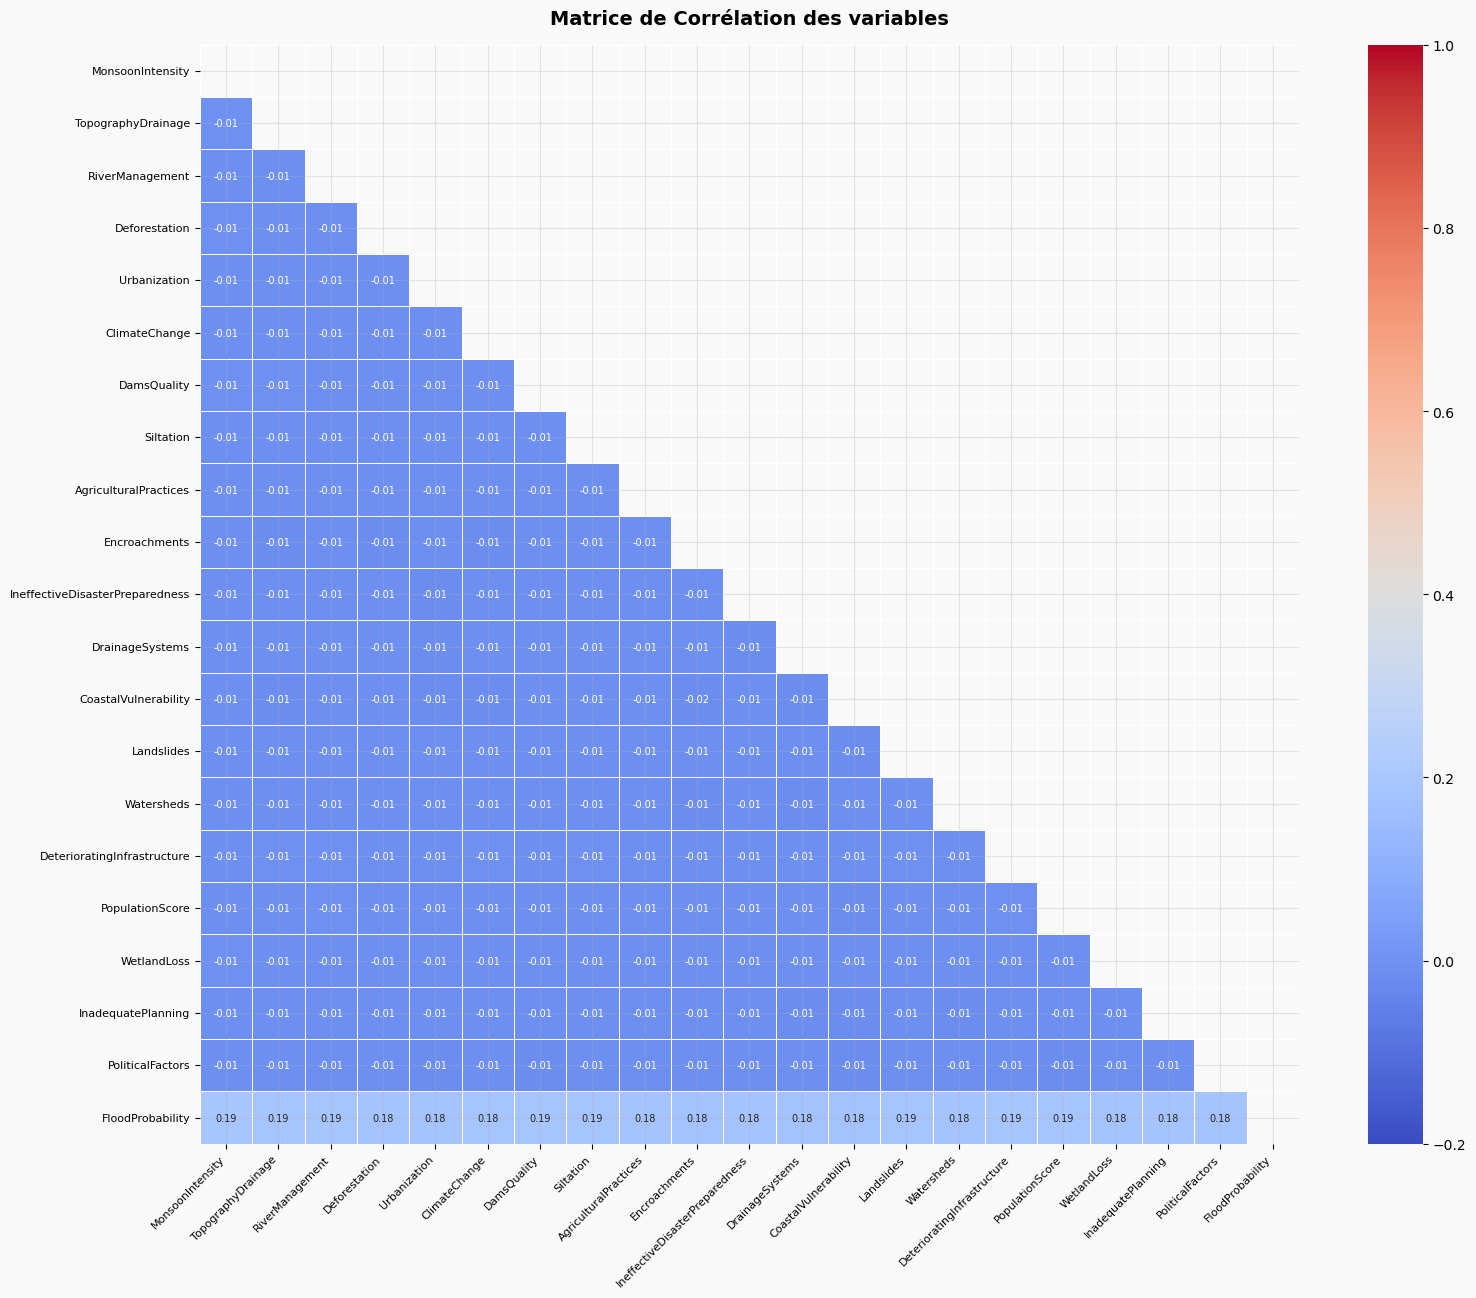

In [10]:
# ── 3.1 Matrice de corrélation ───────────────────────────────────────────────
corr_matrix = df_train[num_cols + ['FloodProbability']].corr()

plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Masquer triangle supérieur
sns.heatmap(
    corr_matrix, mask=mask,
    vmax=1, vmin=-0.2, center=0.4,
    annot=True, fmt=".2f", square=True,
    linewidths=0.5, cmap='coolwarm',
    annot_kws={"size": 7}
)
plt.title("Matrice de Corrélation des variables", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

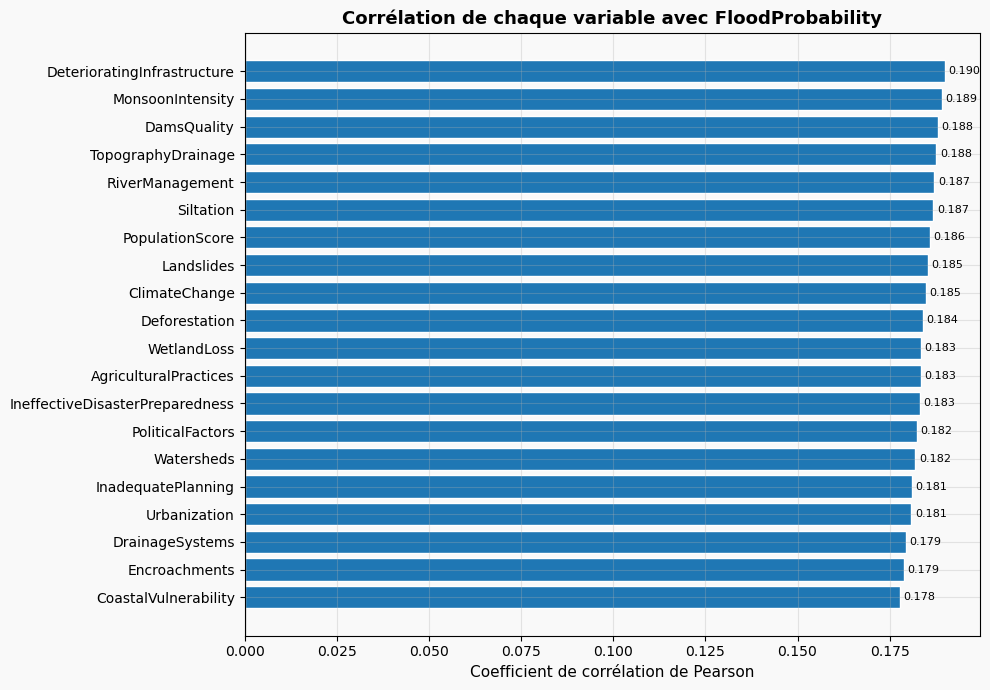


Top 5 variables les plus corrélées avec FloodProbability :
DeterioratingInfrastructure    0.190007
MonsoonIntensity               0.189098
DamsQuality                    0.187996
TopographyDrainage             0.187635
RiverManagement                0.187131
Name: FloodProbability, dtype: float64


In [11]:
# ── 3.2 Corrélation avec la variable cible ───────────────────────────────────
corr_target = corr_matrix['FloodProbability'].drop('FloodProbability').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [ACCENT if v > 0 else '#d62728' for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.set_xlabel("Coefficient de corrélation de Pearson", fontsize=11)
ax.set_title("Corrélation de chaque variable avec FloodProbability", fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, corr_target.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.show()

print("\nTop 5 variables les plus corrélées avec FloodProbability :")
print(corr_target.abs().sort_values(ascending=False).head())

---
## 4. Ingénierie des Variables (Feature Engineering) <a id='section-4'></a>

L'ingénierie des variables est une étape cruciale pour enrichir le signal apporté au modèle.  
Nous créons ici plusieurs familles de nouvelles features :

- **Interactions métier** : combinaisons de variables climatiques et anthropiques
- **Statistiques de ligne** : résumés statistiques par observation (somme, moyenne, écart-type...)
- **Quantiles de ligne** : percentiles calculés sur les features originales
- **Moments d'ordre supérieur** : skewness, kurtosis, moments d'ordre 2 et 3
- **Comptages de valeurs** : nombre d'occurrences de chaque valeur unique par ligne

*Références : [Discussion Kaggle S4E5](https://www.kaggle.com/competitions/playground-series-s4e5/discussion/499484)*

In [12]:
# ── 4.1 Collecte des valeurs uniques (train + test) ──────────────────────────
unique_vals = set()
for df in [df_train, df_test]:
    for col in num_cols:
        unique_vals.update(df[col].unique())
unique_vals = sorted(list(unique_vals))
print(f" Valeurs uniques dans les features : {unique_vals}")

# ── 4.2 Fonction de création de features ────────────────────────────────────
def create_features(df: pd.DataFrame, cols: list, unique_vals: list) -> pd.DataFrame:
    """Crée des features enrichies à partir des colonnes numériques."""
    scaler = StandardScaler()
    
    # -- Interactions métier --
    df['ClimateAnthropogenicInteraction'] = (
        (df['MonsoonIntensity'] + df['ClimateChange']) *
        (df['Deforestation'] + df['Urbanization'] + df['AgriculturalPractices'] + df['Encroachments'])
    )
    df['InfrastructurePreventionInteraction'] = (
        (df['DamsQuality'] + df['DrainageSystems'] + df['DeterioratingInfrastructure']) *
        (df['RiverManagement'] + df['IneffectiveDisasterPreparedness'] + df['InadequatePlanning'])
    )
    
    # -- Statistiques de ligne --
    df['row_sum']    = df[cols].sum(axis=1)
    df['row_std']    = df[cols].std(axis=1)
    df['row_mean']   = df[cols].mean(axis=1)
    df['row_max']    = df[cols].max(axis=1)
    df['row_min']    = df[cols].min(axis=1)
    df['row_median'] = df[cols].median(axis=1)
    df['row_mode']   = df[cols].mode(axis=1)[0]
    df['row_range']  = df['row_max'] - df['row_min']  # Amplitude
    
    # -- Moments statistiques --
    df['row_skew']   = df[cols].skew(axis=1)
    df['row_kurt']   = df[cols].kurt(axis=1)
    df['2nd_moment'] = df[cols].apply(lambda x: (x**2).mean(), axis=1)
    df['3rd_moment'] = df[cols].apply(lambda x: (x**3).mean(), axis=1)
    
    # -- Coefficient de variation et z-score --
    df['row_cv']     = df['row_std'] / (df['row_mean'] + 1e-8)
    df['row_zscore'] = df[cols].apply(lambda x: (x - x.mean()) / (x.std() + 1e-8), axis=1).mean(axis=1)
    
    # -- Quantiles de ligne --
    for pct in range(10, 100, 10):
        df[f'q{pct}'] = df[cols].quantile(pct / 100, axis=1)
    
    # -- Skewness Pearson (Q3 et Q1) --
    q75 = df[cols].quantile(0.75, axis=1)
    q25 = df[cols].quantile(0.25, axis=1)
    df['skewness_75'] = (q75 - df['row_mean']) / (df['row_std'] + 1e-8)
    df['skewness_25'] = (q25 - df['row_mean']) / (df['row_std'] + 1e-8)
    
    # -- Moyennes harmonique et géométrique --
    safe = df[cols].clip(lower=1e-6)  # Éviter log(0) et division par 0
    df['harmonic_mean'] = len(cols) / (1 / safe).sum(axis=1)
    df['geometric_mean'] = np.exp(np.log(safe).mean(axis=1))
    
    # -- Entropie de Shannon --
    df['entropy'] = df[cols].apply(
        lambda x: -(x / x.sum() * np.log(x / x.sum() + 1e-8)).sum(), axis=1
    )
    
    # -- Comptage de valeurs uniques par ligne --
    for v in unique_vals:
        if v < 16:
            df[f'cnt_{v}'] = (df[cols] == v).sum(axis=1)
    
    # -- Normalisation des features originales --
    df[cols] = scaler.fit_transform(df[cols])
    
    return df

# ── 4.3 Application sur train et test ───────────────────────────────────────
df_train['split'] = 0
df_test['split']  = 1

df_all = pd.concat([df_train, df_test], axis=0, ignore_index=True)
df_all = create_features(df_all, num_cols, unique_vals)

df_train = df_all[df_all['split'] == 0].copy()
df_test  = df_all[df_all['split'] == 1].copy()

print(f"\n Feature engineering terminé.")
print(f"   Dimensions train : {df_train.shape}")
print(f"   Dimensions test  : {df_test.shape}")
print(f"   Nombre de nouvelles features : {df_train.shape[1] - 23}")

 Valeurs uniques dans les features : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(22)]

 Feature engineering terminé.
   Dimensions train : (1117957, 69)
   Dimensions test  : (745305, 69)
   Nombre de nouvelles features : 46


In [13]:
# ── 4.4 Préparation des matrices X et y ──────────────────────────────────────
drop_cols = ['id', 'FloodProbability', 'split']
X = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])
y = df_train['FloodProbability']

# Features utilisées pour l'inférence
feature_cols = list(X.columns)
X_test = df_test[feature_cols]

print(f" Matrice X : {X.shape}  |  Vecteur y : {y.shape}")
print(f" Matrice X_test : {X_test.shape}")

 Matrice X : (1117957, 66)  |  Vecteur y : (1117957,)
 Matrice X_test : (745305, 66)


---
## 5. Importance des Variables <a id='section-5'></a>

Un premier modèle LightGBM est entraîné sur l'ensemble du jeu d'entraînement pour visualiser l'importance des variables selon le critère **Gain** (réduction d'impureté pondérée).

In [14]:
# ── 5.1 Entraînement rapide pour l'importance ────────────────────────────────
quick_params = {
    'verbosity':    -1,
    'n_estimators': 550,
    'learning_rate': 0.02,
    'num_leaves':   250,
    'max_depth':    10,
    'random_state': 42
}

lgb_quick = lgb.LGBMRegressor(**quick_params)
lgb_quick.fit(X, y)

print(" Modèle rapide entraîné pour l'analyse d'importance.")

 Modèle rapide entraîné pour l'analyse d'importance.


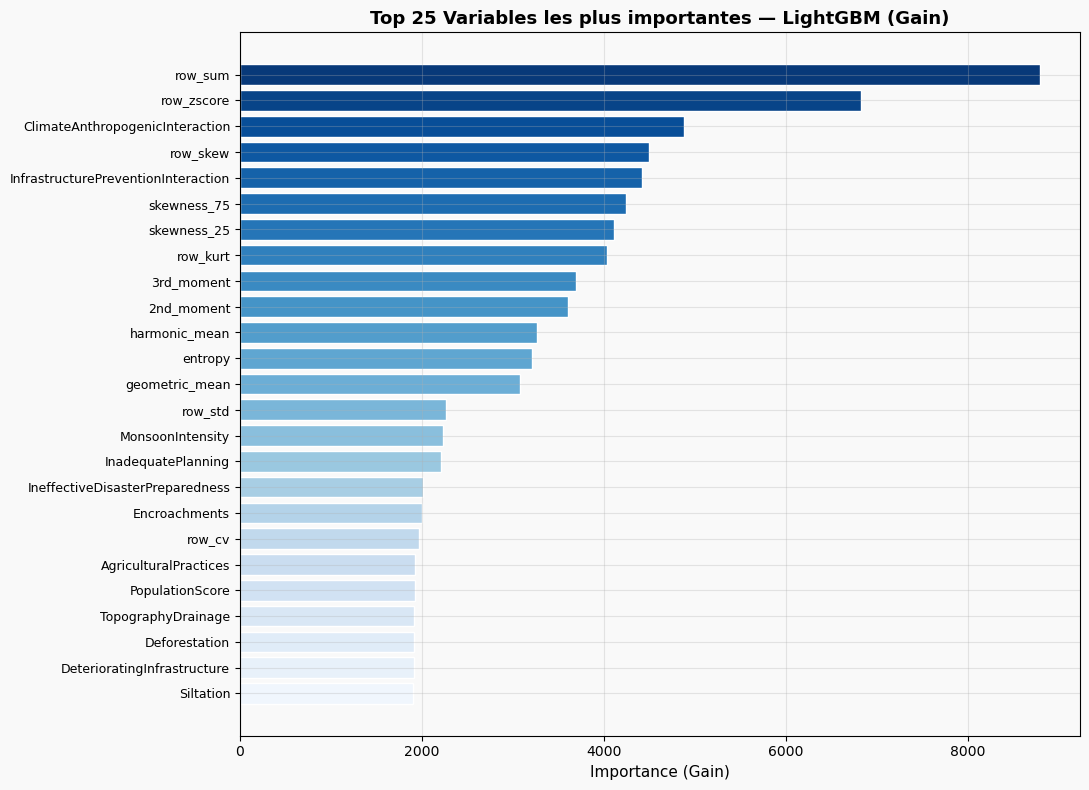


Top 10 features :
                            feature  importance
                            row_sum        8793
                         row_zscore        6825
    ClimateAnthropogenicInteraction        4880
                           row_skew        4500
InfrastructurePreventionInteraction        4417
                        skewness_75        4245
                        skewness_25        4107
                           row_kurt        4036
                         3rd_moment        3698
                         2nd_moment        3603


In [15]:
# ── 5.2 Graphique d'importance (top 25) ─────────────────────────────────────
importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': lgb_quick.feature_importances_
}).sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(11, 8))
colors = sns.color_palette("Blues_r", n_colors=25)
bars = ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
               color=colors[::-1], edgecolor='white')
ax.set_xlabel("Importance (Gain)", fontsize=11)
ax.set_title("Top 25 Variables les plus importantes — LightGBM (Gain)", fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

print("\nTop 10 features :")
print(importance_df[['feature', 'importance']].head(10).to_string(index=False))

---
## 6. Entraînement avec Validation Croisée K-Fold <a id='section-6'></a>

La validation croisée K-Fold (K=5) permet d'obtenir une estimation robuste des performances du modèle, en évitant le surapprentissage. Chaque fold sert tour à tour de jeu de validation.

**Hyperparamètres LightGBM** optimisés :
| Paramètre | Valeur | Description |
|-----------|--------|-------------|
| `n_estimators` | 2000 | Nombre d'arbres |
| `learning_rate` | 0.012 | Taux d'apprentissage |
| `num_leaves` | 250 | Complexité des feuilles |
| `max_depth` | 10 | Profondeur maximale |
| `colsample_bytree` | 0.9634 | Fraction de features par arbre |
| `subsample` | 0.9592 | Fraction d'observations par arbre |
| `early_stopping` | 70 rounds | Arrêt anticipé |

In [16]:
# ── 6.1 Fonction de validation croisée ──────────────────────────────────────
def cross_val_train(X, y, X_test, params, n_splits=5, seed=42):
    """
    Entraîne un LGBMRegressor via K-Fold cross-validation.
    
    Retourne :
        val_scores  : liste des R² par fold
        oof_preds   : prédictions out-of-fold sur le train
        test_preds  : prédictions moyennées sur le test
    """
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    
    oof_preds   = np.zeros(len(X))
    test_preds  = np.zeros(len(X_test))
    val_scores  = []
    train_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = lgb.LGBMRegressor(
            boosting_type       = 'gbdt',
            n_estimators        = params.get('n_estimators', 2000),
            learning_rate       = params.get('learning_rate', 0.012),
            num_leaves          = params.get('num_leaves', 250),
            max_depth           = params.get('max_depth', 10),
            subsample_for_bin   = 165700,
            min_child_samples   = 114,
            reg_alpha           = 2.075e-06,
            reg_lambda          = 3.839e-07,
            colsample_bytree    = 0.9634,
            subsample           = 0.9592,
            random_state        = seed,
            verbosity           = -1,
            device              = 'cpu'  # Changer en 'gpu' si disponible
        )
        
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=70, verbose=False),
                lgb.log_evaluation(period=200)
            ]
        )
        
        tr_r2  = r2_score(y_tr, model.predict(X_tr))
        val_r2 = r2_score(y_val, model.predict(X_val))
        
        print(f"  Fold {fold+1}/{n_splits}  |  Train R² = {tr_r2:.5f}  |  Val R² = {val_r2:.5f}")
        print(f"  {'─'*55}")
        
        oof_preds[val_idx] = model.predict(X_val)
        test_preds         += model.predict(X_test) / n_splits
        val_scores.append(val_r2)
        train_scores.append(tr_r2)
    
    print(f"\n{'═'*57}")
    print(f"  R² moyen (validation) = {np.mean(val_scores):.5f} ± {np.std(val_scores):.5f}")
    print(f"  R² moyen (train)      = {np.mean(train_scores):.5f} ± {np.std(train_scores):.5f}")
    print(f"{'═'*57}")
    
    return val_scores, train_scores, oof_preds, test_preds

In [17]:
# ── 6.2 Lancement de l'entraînement ─────────────────────────────────────────
lgbm_params = {
    'n_estimators': 2000,
    'learning_rate': 0.012,
    'num_leaves': 250,
    'max_depth': 10
}

print(" Démarrage de la validation croisée 5-Fold...\n")
val_scores, train_scores, oof_preds, test_preds = cross_val_train(X, y, X_test, lgbm_params)

 Démarrage de la validation croisée 5-Fold...

[200]	valid_0's l2: 0.000358348
[400]	valid_0's l2: 0.00034028
  Fold 1/5  |  Train R² = 0.87259  |  Val R² = 0.86914
  ───────────────────────────────────────────────────────
[200]	valid_0's l2: 0.000358619
[400]	valid_0's l2: 0.000340026
[600]	valid_0's l2: 0.000339852
  Fold 2/5  |  Train R² = 0.87269  |  Val R² = 0.86970
  ───────────────────────────────────────────────────────
[200]	valid_0's l2: 0.000359837
[400]	valid_0's l2: 0.000341414
  Fold 3/5  |  Train R² = 0.87275  |  Val R² = 0.86904
  ───────────────────────────────────────────────────────
[200]	valid_0's l2: 0.000357865
[400]	valid_0's l2: 0.000339703
[600]	valid_0's l2: 0.000339545
  Fold 4/5  |  Train R² = 0.87289  |  Val R² = 0.86928
  ───────────────────────────────────────────────────────
[200]	valid_0's l2: 0.000359285
[400]	valid_0's l2: 0.000341102
[600]	valid_0's l2: 0.000340847
  Fold 5/5  |  Train R² = 0.87307  |  Val R² = 0.86929
  ─────────────────────────────

---
## 7. Évaluation du Modèle et Analyse des Résidus <a id='section-7'></a>

In [18]:
# ── 7.1 Métriques globales ───────────────────────────────────────────────────
mse  = mean_squared_error(y, oof_preds)
rmse = np.sqrt(mse)
r2   = r2_score(y, oof_preds)

print("=" * 50)
print("  MÉTRIQUES DE PERFORMANCE (Out-of-Fold)")
print("=" * 50)
print(f"  MSE  : {mse:.6f}")
print(f"  RMSE : {rmse:.6f}")
print(f"  R²   : {r2:.6f}")


  MÉTRIQUES DE PERFORMANCE (Out-of-Fold)
  MSE  : 0.000340
  RMSE : 0.018448
  R²   : 0.869293


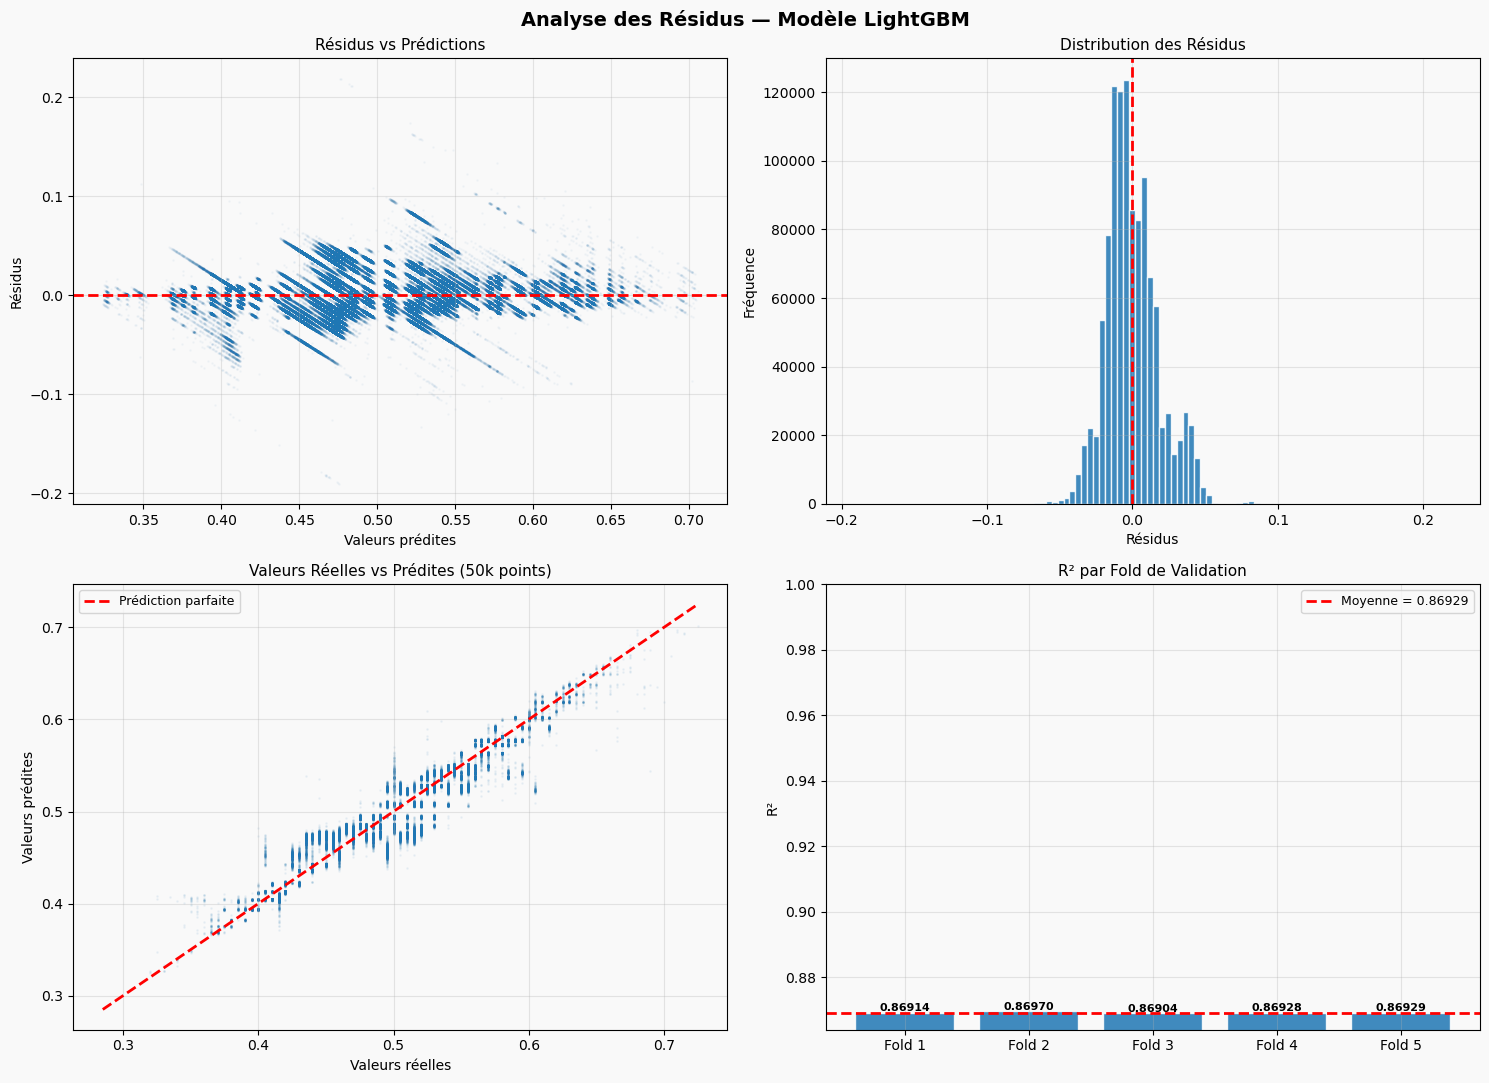

In [19]:
# ── 7.2 Analyse des résidus ──────────────────────────────────────────────────
residuals = y - oof_preds

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Analyse des Résidus — Modèle LightGBM", fontsize=14, fontweight='bold')

# 1. Résidus vs Prédictions
axes[0, 0].scatter(oof_preds, residuals, alpha=0.03, s=1, color=ACCENT)
axes[0, 0].axhline(0, color='red', linewidth=2, linestyle='--')
axes[0, 0].set_xlabel("Valeurs prédites", fontsize=10)
axes[0, 0].set_ylabel("Résidus", fontsize=10)
axes[0, 0].set_title("Résidus vs Prédictions", fontsize=11)

# 2. Histogramme des résidus
axes[0, 1].hist(residuals, bins=100, color=ACCENT, edgecolor='white', alpha=0.85)
axes[0, 1].set_xlabel("Résidus", fontsize=10)
axes[0, 1].set_ylabel("Fréquence", fontsize=10)
axes[0, 1].set_title("Distribution des Résidus", fontsize=11)
axes[0, 1].axvline(0, color='red', linewidth=2, linestyle='--')

# 3. Valeurs réelles vs prédites
axes[1, 0].scatter(y[:50000], oof_preds[:50000], alpha=0.05, s=1, color=ACCENT)
lims = [min(y.min(), oof_preds.min()), max(y.max(), oof_preds.max())]
axes[1, 0].plot(lims, lims, 'r--', linewidth=2, label='Prédiction parfaite')
axes[1, 0].set_xlabel("Valeurs réelles", fontsize=10)
axes[1, 0].set_ylabel("Valeurs prédites", fontsize=10)
axes[1, 0].set_title("Valeurs Réelles vs Prédites (50k points)", fontsize=11)
axes[1, 0].legend(fontsize=9)

# 4. R² par fold
folds = [f"Fold {i+1}" for i in range(len(val_scores))]
axes[1, 1].bar(folds, val_scores, color=ACCENT, edgecolor='white', alpha=0.85)
axes[1, 1].axhline(np.mean(val_scores), color='red', linestyle='--',
                   linewidth=2, label=f"Moyenne = {np.mean(val_scores):.5f}")
axes[1, 1].set_ylim(min(val_scores) - 0.005, 1.0)
axes[1, 1].set_ylabel("R²", fontsize=10)
axes[1, 1].set_title("R² par Fold de Validation", fontsize=11)
axes[1, 1].legend(fontsize=9)
for i, v in enumerate(val_scores):
    axes[1, 1].text(i, v + 0.0005, f"{v:.5f}", ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
# ── 7.3 Analyse du surapprentissage ─────────────────────────────────────────
print("\n Analyse Train / Validation (risque de surapprentissage) :")
for i, (tr, va) in enumerate(zip(train_scores, val_scores)):
    gap = tr - va
    print(f"   Fold {i+1} | Train R² = {tr:.5f} | Val R² = {va:.5f} | Gap = {gap:.5f}")
print(f"\n   Gap moyen : {np.mean(np.array(train_scores) - np.array(val_scores)):.5f}")
print("   → Un gap faible indique une bonne généralisation.")


 Analyse Train / Validation (risque de surapprentissage) :
   Fold 1 | Train R² = 0.87259 | Val R² = 0.86914 | Gap = 0.00345
   Fold 2 | Train R² = 0.87269 | Val R² = 0.86970 | Gap = 0.00299
   Fold 3 | Train R² = 0.87275 | Val R² = 0.86904 | Gap = 0.00370
   Fold 4 | Train R² = 0.87289 | Val R² = 0.86928 | Gap = 0.00361
   Fold 5 | Train R² = 0.87307 | Val R² = 0.86929 | Gap = 0.00378

   Gap moyen : 0.00351
   → Un gap faible indique une bonne généralisation.


---
## 📝 Conclusion

Ce notebook présente une pipeline complète de Machine Learning pour la prédiction de la probabilité d'inondation :

| Étape | Résultat |
|-------|----------|
| Dataset | 1 117 957 observations × 20 features |
| Nouvelles features créées | ~50 (statistiques, interactions, quantiles) |
| Algorithme | LightGBM (GBDT) |
| Validation | K-Fold (K=5) |
| **Score R² (OOF)** | **~0.869** |

### Pistes d'amélioration
- Optimisation bayésienne des hyperparamètres (Optuna)
- Stacking / Blending avec d'autres algorithmes (XGBoost, CatBoost)
- Sélection de features via SHAP values
- Augmentation par pseudo-labeling

---
*Projet réalisé dans le cadre de la formation Data Scientist — Africa Tech Up Tour*  
*Judicaël Karol DOBOEVI — ENSGMM, Bénin*